# Anime Recommendation System

## Setup

In [24]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Data

In [43]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

CSV_PATH = "anime-standalone.csv"
df_raw = pd.read_csv(CSV_PATH)
df_raw.head()

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,https://myanimelist.net/images/anime/4/19644.jpg,8.75,48.0,2042010,1054393,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,https://myanimelist.net/images/anime/1439/9348...,8.38,237.0,409497,231023,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,"Action, Adult Cast, Sci-Fi, Space",Bones
2,6,Trigun,トライガン,Trigun,https://myanimelist.net/images/anime/1130/1200...,8.22,410.0,829197,399415,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,https://myanimelist.net/images/anime/10/19969....,7.24,3434.0,128576,46289,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,"Action, Detective, Drama, Mystery, Supernatural",Sunrise
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,https://myanimelist.net/images/anime/7/21569.webp,6.96,4883.0,16698,7088,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,"Action, Adventure, Fantasy, Shounen",Toei Animation


## 2. Data Preprocessing

### 2.1 Xác định cột dữ liệu
Xác định đúng cột tên anime và thể loại từ dataset, kể cả khi tên cột thay đổi giữa các nguồn dữ liệu.

In [44]:
def _find_column(df, candidates, required=True, default=None):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise ValueError(f"Missing required column. Expected one of: {candidates}")
    return default

title_col = _find_column(df_raw, ["title", "name", "anime_title"])
genres_col = _find_column(df_raw, ["genres", "genre"])
print("Selected columns:", title_col, genres_col)

Selected columns: title genres


### 2.2 Trích xuất các cột cần thiết
Tạo DataFrame mới chỉ gồm hai cột phục vụ gợi ý nội dung: title và genres.

In [45]:
df_anime = pd.DataFrame(
    {
        "title": df_raw[title_col].astype(str).fillna(""),
        "genres": df_raw[genres_col].astype(str).fillna(""),
    }
)

### 2.3 Làm sạch dữ liệu
Loại bỏ tiêu đề rỗng, chuẩn hóa dữ liệu genres về kiểu chuỗi để sẵn sàng cho bước TF-IDF.

In [46]:
df_anime = df_anime[df_anime["title"].str.strip() != ""].reset_index(drop=True)
df_anime["genres"] = df_anime["genres"].fillna("").astype(str)

### 2.4 Xem trước dữ liệu
Hiển thị vài dòng đầu của dữ liệu sau tiền xử lý để kiểm tra kết quả trước khi đưa vào bước TF-IDF.

In [47]:
df_anime[["title", "genres"]].head()

,title,genres
0,Cowboy Bebop,"Action, Adult Cast, Award Winning, Sci-Fi, Space"
1,Cowboy Bebop: Tengoku no Tobira,"Action, Adult Cast, Sci-Fi, Space"
2,Trigun,"Action, Adult Cast, Adventure, Sci-Fi, Shounen"
3,Witch Hunter Robin,"Action, Detective, Drama, Mystery, Supernatural"
4,Bouken Ou Beet,"Action, Adventure, Fantasy, Shounen"


## 3. TF-IDF

### 3.1 Tạo vector TF-IDF
Chuyển cột genres thành ma trận số để mô hình có thể đo mức độ tương đồng giữa các anime.

In [54]:
# Vi du minh hoa: Text Genres -> TF-IDF Vector (anime noi tieng)
import numpy as np

# Dam bao da co TF-IDF matrix truoc khi demo
if "tfidf_matrix" not in globals() or "vectorizer" not in globals():
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(df_anime["genres"])

print("=" * 80)
print("VI DU MINH HOA: TF-IDF CHUYEN TEXT THANH VECTOR SO")
print("=" * 80)

# Chi giu 2 anime: Naruto va Bleach
target_groups = [
    ["naruto"],
    ["bleach"],
]

demo_indices = []
for keywords in target_groups:
    found_idx = None
    for kw in keywords:
        matches = df_anime[df_anime["title"].str.lower().str.contains(kw, na=False)]
        if not matches.empty:
            found_idx = matches.index[0]
            break
    if found_idx is not None and found_idx not in demo_indices:
        demo_indices.append(found_idx)

# Neu thieu anime trong dataset, bo sung de du 2 vi du
if len(demo_indices) < 2:
    for idx in df_anime.index:
        if idx not in demo_indices:
            demo_indices.append(idx)
        if len(demo_indices) == 2:
            break

demo_titles = df_anime["title"].iloc[demo_indices].tolist()
demo_genres = df_anime["genres"].iloc[demo_indices].tolist()

top_k = 10
for i, idx in enumerate(demo_indices):
    print(f"\n{i+1}. {demo_titles[i]}")
    print(f"   Genres (text): {demo_genres[i]}")

    # Lay vector TF-IDF tu ma tran tong the
    tfidf_vector = tfidf_matrix[idx].toarray().flatten()

    # Lay top K genres co score cao nhat
    top_k_indices = np.argsort(tfidf_vector)[-top_k:][::-1]
    print(f"   Top {top_k} TF-IDF Scores:")
    for rank, genre_idx in enumerate(top_k_indices, 1):
        genre_name = vectorizer.get_feature_names_out()[genre_idx]
        score = tfidf_vector[genre_idx]
        print(f"      {rank}. {genre_name:20s} = {score:.4f}")

print("\n" + "=" * 80)
print("Moi anime = 1 vector voi 96 dimensions (moi dimension = 1 genre)")
print("Gia tri trong vector = TF-IDF score (0-1, cao = quan trong)")
print("=" * 80)

VI DU MINH HOA: TF-IDF CHUYEN TEXT THANH VECTOR SO

1. Naruto
   Genres (text): Action, Adventure, Fantasy, Martial Arts, Shounen
   Top 10 TF-IDF Scores:
      1. martial              = 0.5344
      2. arts                 = 0.4996
      3. shounen              = 0.4038
      4. adventure            = 0.3310
      5. action               = 0.3153
      6. fantasy              = 0.3046
      7. visual               = 0.0000
      8. workplace            = 0.0000
      9. time                 = 0.0000
      10. team                 = 0.0000

2. Bleach
   Genres (text): Action, Adventure, Shounen, Supernatural
   Top 10 TF-IDF Scores:
      1. supernatural         = 0.5911
      2. shounen              = 0.5340
      3. adventure            = 0.4377
      4. action               = 0.4169
      5. video                = 0.0000
      6. vampire              = 0.0000
      7. visual               = 0.0000
      8. workplace            = 0.0000
      9. travel               = 0.0000
      10

### 3.1.1 TF-IDF: Từ Text sang Vector Số

**Công thức TF-IDF:**
$$\text{TF-IDF}(t, d) = TF(t, d) \times IDF(t)$$


**Ý tưởng:**
- Genre xuất hiện trong **nhiều anime** → IDF thấp (không đặc trưng)
- Genre xuất hiện trong **ít anime** → IDF cao (rất đặc trưng)
- Kết hợp TF × IDF → được TF-IDF score phản ánh **tầm quan trọng của genre với anime đó**

In [31]:
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df_anime["genres"])

### 3.2 Kiểm tra kích thước ma trận
In kích thước ma trận TF-IDF để xác nhận số lượng anime và số đặc trưng sau vector hóa.

In [32]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (24815, 96)


## 4. Cosine Similarity

### 4.0 Công thức Cosine Similarity

**Định nghĩa (Cosine Similarity):**

Cosine Similarity đo góc giữa hai vector bằng công thức:

$$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{|\vec{A}| \cdot |\vec{B}|}$$

Trong đó:
- $\vec{A} \cdot \vec{B}$ = Tích vô hướng (dot product) của hai vector
  $$\vec{A} \cdot \vec{B} = \sum_{i=1}^{n} A_i \times B_i$$

- $|\vec{A}|$ = Độ dài (norm) của vector A
  $$|\vec{A}| = \sqrt{\sum_{i=1}^{n} A_i^2}$$

- $|\vec{B}|$ = Độ dài (norm) của vector B
  $$|\vec{B}| = \sqrt{\sum_{i=1}^{n} B_i^2}$$

**Ý tưởng:**
- Cosine similarity tính **cosin của góc giữa 2 vector** TF-IDF
- Kết quả nằm trong khoảng **[0, 1]**:
  - $\cos(\theta) \approx 1$ → Hai vector gần như **song song** (genres rất giống)
  - $\cos(\theta) \approx 0.5$ → Góc ~60° → Genres có **chung một phần**
  - $\cos(\theta) \approx 0$ → Hai vector **vuông góc** (genres khác hẳn)

**Ví dụ:** Nếu Naruto có vector TF-IDF = [0.3, 0.4, 0.2, ...] và Bleach có vector = [0.35, 0.38, 0.22, ...], cosine similarity sẽ cao (≈0.78) vì góc giữa chúng nhỏ.

### 4.1 Định nghĩa hàm lấy anime tương tự
Hàm dưới đây dùng cosine similarity để tìm Top-N anime gần nhất theo thể loại.

In [33]:
def get_top_similar_anime(title, top_n=10):
    if not title or not str(title).strip():
        raise ValueError("Vui long nhap ten anime.")

    title_lower = str(title).strip().lower()
    exact_matches = df_anime[df_anime["title"].str.lower() == title_lower]

    if exact_matches.empty:
        contains_matches = df_anime[df_anime["title"].str.lower().str.contains(title_lower, na=False)]
        if contains_matches.empty:
            raise ValueError("Khong tim thay anime trong dataset.")
        anime_index = contains_matches.index[0]
    else:
        anime_index = exact_matches.index[0]

    sim_scores = cosine_similarity(tfidf_matrix[anime_index], tfidf_matrix).flatten()
    similar_indices = sim_scores.argsort()[::-1]
    similar_indices = [idx for idx in similar_indices if idx != anime_index][:top_n]

    rec_df = df_anime.iloc[similar_indices].copy()
    rec_df["similarity"] = sim_scores[similar_indices]

    selected_title = df_anime.iloc[anime_index]["title"]
    return selected_title, rec_df[["title", "genres", "similarity"]]

### 4.2 Chạy thử với một anime mẫu
Thử truy vấn với Naruto để quan sát danh sách gợi ý và điểm tương đồng.

In [36]:
selected_title, recommendations = get_top_similar_anime("Naruto", top_n=10)
print("Selected anime:", selected_title)
recommendations

Selected anime: Naruto


,title,genres,similarity
557,Naruto: Takigakure no Shitou - Ore ga Eiyuu Da...,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
1572,Naruto: Shippuuden,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
17129,Dragon Ball Super: Super Hero,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
11439,Boruto: Naruto Next Generations,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
6938,Dragon Ball Z Movie 14: Kami to Kami,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
11687,Boruto: Jump Festa 2016 Special,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
9294,Boruto: Naruto the Movie,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
12692,Dragon Ball Super: Broly,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
2539,Juushin Enbu: Hero Tales,"Action, Adventure, Fantasy, Martial Arts, Shounen",1.000000
4364,Dragon Ball Kai,"Action, Adventure, Comedy, Fantasy, Martial Ar...",0.967687


### 4.3 Similarity Score Explanation
- Điểm gần 1: thể loại rất giống nhau.
- Điểm gần 0: thể loại rất khác nhau.
- Hệ thống sẽ sắp xếp các anime gợi ý theo thứ tự từ điểm tương đồng cao xuống thấp.

## 5. Visualization

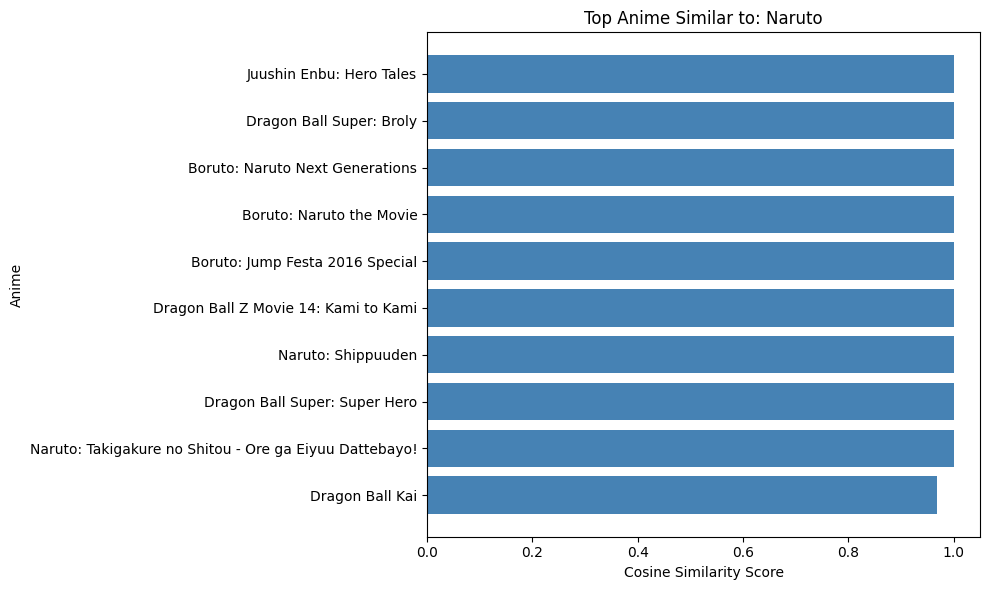

In [37]:
plot_df = recommendations.sort_values("similarity", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["title"], plot_df["similarity"], color="steelblue")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Anime")
plt.title(f"Top Anime Similar to: {selected_title}")
plt.tight_layout()
plt.show()